

# Exercise 2

## STR population structure


**I choose chr1 for this exercise**

Read data

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import sklearn

dir = 'C:/Users/franc/OneDrive/Dokumente/UZH/26FS/BIO392BioinformaticsOfMolecularSequenceVariation/UZH-BIO392-FS26/course-results/francesco_nocera/20260429/'

# Load data
sample_type = pd.read_csv(dir + 'sample_type.csv')
kg_matrix   = pd.read_csv(dir + 'kg_matrix_chr1.csv', index_col=0)

print(sample_type)


       sample Population Superpopulation  coding_one_allele_non_ref  \
0     NA11892        CEU             EUR                      153.0   
1     HG03049        GWD             AFR                      196.0   
2     HG02813        GWD             AFR                      173.0   
3     NA10865        CEU             EUR                      152.0   
4     HG04160        BEB             SAS                      151.0   
...       ...        ...             ...                        ...   
3547  HG00128        GBR             EUR                      133.0   
3548  HG00420        CHS             EAS                      123.0   
3549  HG02106        PEL             AMR                      126.0   
3550      NaN        NaN             NaN                        NaN   
3551      NaN        NaN             NaN                        NaN   

      coding_two_alleles_non_ref  wg_one_allele_non_ref  \
0                          122.0               171794.0   
1                          13

In [85]:


print(sample_type.shape)
print(sample_type.columns)
print(kg_matrix.shape)
print(kg_matrix.columns)

(3552, 7)
Index(['sample', 'Population', 'Superpopulation', 'coding_one_allele_non_ref',
       'coding_two_alleles_non_ref', 'wg_one_allele_non_ref',
       'wg_two_alleles_non_ref'],
      dtype='str')
(30635, 3202)
Index(['NA19024', 'HG03117', 'NA19120', 'HG03492', 'NA19238', 'NA19148',
       'HG01956', 'HG00284', 'NA19404', 'HG01530',
       ...
       'HG02220', 'NA18548', 'NA18966', 'HG03123', 'HG02923', 'HG00409',
       'HG01872', 'HG01805', 'HG02429', 'NA18957'],
      dtype='str', length=3202)


In [86]:
kg_matrix.isna().sum()



NA19024    336
HG03117    522
NA19120    634
HG03492    246
NA19238    634
          ... 
HG00409    422
HG01872    271
HG01805    311
HG02429    398
NA18957    281
Length: 3202, dtype: int64

## Filtering


I will filter loci out that have missing values (PCA or logistic regression cannot handle nan)
I need to transpose to get pca format (because matrix multiplication in linear alegbra)
i will filter loci that are the same everywhere

In [87]:
X_raw = kg_matrix.T

print(X_raw.shape)

keep_loci = X_raw.columns[X_raw.isnull().any(axis=0) == False]
X_filtered = X_raw[keep_loci]
print(X_filtered.shape)



(3202, 30635)
(3202, 19765)


align the samples and locus matrix

In [88]:
sample_ids = X_filtered.index.tolist()  # sample IDs from kg_matrix (after transpose)

sample_type_indexed = sample_type.set_index('sample')

#to keep only sampels present in both
common_samples = [s for s in sample_ids if s in sample_type_indexed.index]
print(len(sample_ids))
print(len(sample_type_indexed))
print(len(common_samples))

X_common = X_filtered.loc[common_samples]

labels_superpop = sample_type_indexed.loc[common_samples, 'Superpopulation'].values
labels_pop      = sample_type_indexed.loc[common_samples, 'Population'].values

print(pd.Series(labels_superpop).value_counts())

3202
3552
3202
AFR    893
EUR    633
SAS    601
EAS    585
AMR    490
Name: count, dtype: int64


## PCA analysis

i should scale and standardize the values around 0, 


In [89]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_common)

X_scaled.shape

(3202, 19765)

the pca

In [90]:
from sklearn.decomposition import PCA

n_components = 10
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)


print(pca.explained_variance_ratio_ * 100)


explained = pca.explained_variance_ratio_


[8.68581046 3.20912699 0.93884844 0.73948585 0.28566631 0.19044562
 0.16078818 0.1575039  0.15146192 0.14703437]


seems like the first two pc's are most important, as expected, not sure if third or fourth pc are important with less than 1% variance explanantion, i will focus on pc1 and pc2. 

visually:

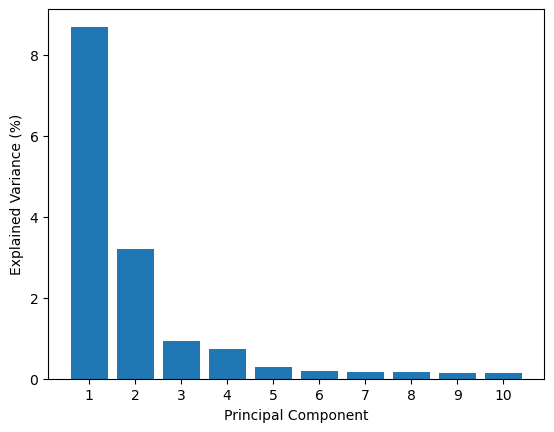

In [91]:


plt.bar(x = range(1, n_components + 1), height = explained * 100)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.xticks(range(1, n_components + 1))
plt.show()

combine the pca with metadata (visually)

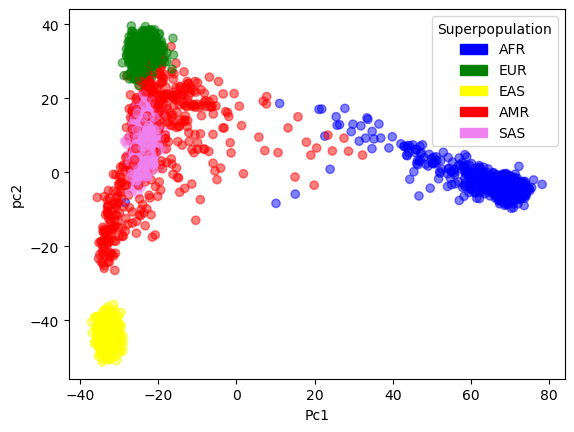

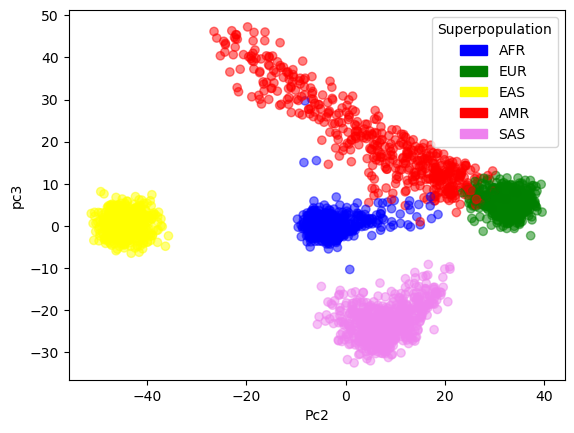

In [92]:
superpop_colors = {
    'AFR': 'blue',
    'EUR': 'green',
    'EAS': 'yellow',
    'AMR': 'red',
    'SAS': 'violet',
}

colors = [superpop_colors[sp] for sp in labels_superpop]


plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5)
plt.xlabel('Pc1')
plt.ylabel('pc2')
legend_handles = [mpatches.Patch(color=c, label=sp) for sp, c in superpop_colors.items()]
plt.legend(handles=legend_handles, title='Superpopulation')
plt.show()


plt.scatter(X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.5)
plt.xlabel('Pc2')
plt.ylabel('pc3')
legend_handles = [mpatches.Patch(color=c, label=sp) for sp, c in superpop_colors.items()]
plt.legend(handles=legend_handles, title='Superpopulation')
plt.show()


seems like pc 3 helps distinguish the americas (amr) better from , so even values smaller than 1% are meaningful i guess.

## Clustering Analysis

i use the k-means method from sklearn

in the previous exercise 5 groups seemed useful, so i use k= 5 ( and we have 5 superpopulatins)

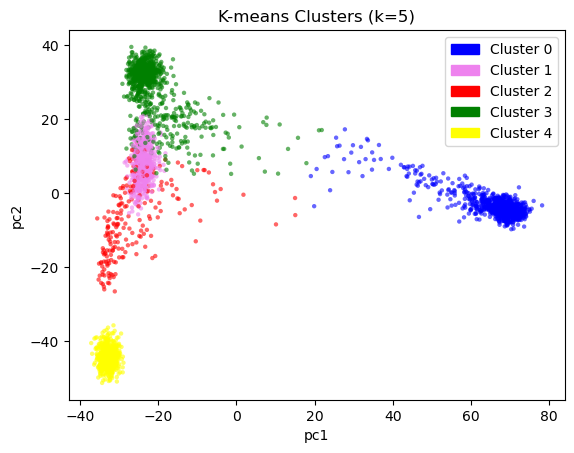

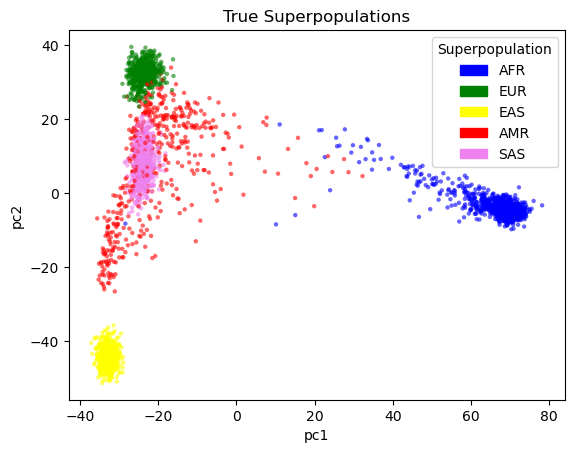

In [93]:
from sklearn.cluster import KMeans


k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Plot clusters on PC1 vs PC2
cluster_colors = ['blue', 'violet', 'red', 'green', 'yellow']
colors_cluster = [cluster_colors[c] for c in cluster_labels]

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-means clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_cluster, alpha=0.6, s=10, linewidths=0)
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('K-means Clusters (k=5)')
legend = [mpatches.Patch(color=cluster_colors[i], label=f'Cluster {i}') for i in range(k)]
plt.legend(handles=legend)
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors, alpha=0.6, s=10, linewidths=0)
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('True Superpopulations')
plt.legend(handles=legend_handles, title='Superpopulation')
plt.show()



seems indeed that STR presence mirrors the metadata, red and green (eur and amr) are a bit confused

## Supervised classification


i will use a logisic regression like last week



split the data into train and test part, i will do 70/30 (dont know really what ratio one should do)

In [94]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_pca, labels_superpop,
    test_size=0.30,
    random_state=1234,
    stratify=labels_superpop
)

print('train', len(X_train))
print('test', len(X_test))


train 2241
test 961


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# max_iter increased because convergence can be slow with many classes
clf = LogisticRegression(max_iter= 1000, random_state=42, solver='lbfgs')
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         AFR       0.99      0.98      0.98       268
         AMR       0.96      0.95      0.95       147
         EAS       1.00      1.00      1.00       176
         EUR       0.98      0.99      0.99       190
         SAS       1.00      1.00      1.00       180

    accuracy                           0.99       961
   macro avg       0.98      0.98      0.98       961
weighted avg       0.99      0.99      0.99       961



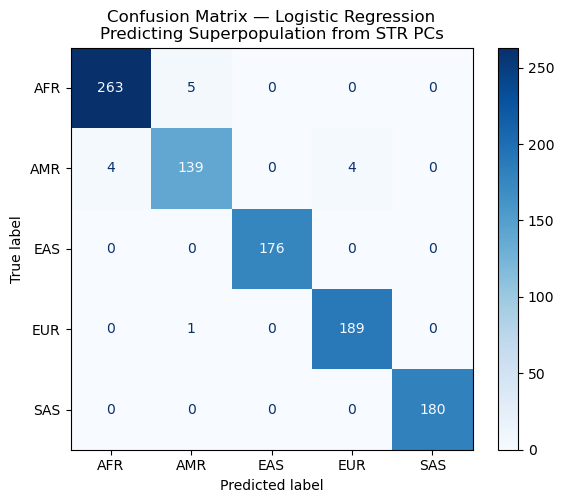

In [96]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


superpops = sorted(set(labels_superpop))
cm = confusion_matrix(y_test, y_pred, labels=superpops)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=superpops)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression\nPredicting Superpopulation from STR PCs')
plt.tight_layout()
plt.show()

In [97]:
y_pred_all = clf.predict(X_pca)

correct = (y_pred_all == labels_superpop)

print(correct.sum()/len(correct) * 100)

99.21923797626484


seems very very accurate, dont know if i should trust it

### conclusions

**data filtering** 

started with ~30'000 loci, filered for missing values, left with 19'765 loci

**pca** 

The first two principal components explain 8.7% and 3.2% of variance, but pc3 still helpts to distinguish AMR better


**kmeans**

the population structure is reflected very good by kmeans (k=5), only europe and americas seem to be harder to separate correctly, but many parts of the americas were european colonies, so maybe there was a lot of gene flow in this superpopulaiton

**classifier**

seems to have worked too good, i don't trust that high accuracy(or genetics are just that clear)
